# Inputs and outputs of the AMPK–ULK1–MTOR oscillator SCC

`0X_cyclical_attractor_analysis` and `02_structural_scc_analysis` found that the cyclic attractors (all three readouts free) are driven by one
7-node strongly connected component (SCC) of the cycling subnetwork:
`PRKA, ULK1, MTOR, RPTOR, TSC2, RHEB, FKBP8`. `03_attractor_activity_decision` showed that the fate decision is taken by
the nodes *around* this SCC. This notebook treats the SCC as a module and characterises its ports
in the **September model** (`model/autophagy_september26/Autophagy_and_apoptosis_Sept26.bnet`):

1. Find the oscillator SCC again (same recipe as `02_structural_scc_analysis`) and show its internal wiring.
2. **Inputs**: every edge that enters the SCC from outside. Which node sends it, where in the SCC
   it lands, with which sign, what drives the sender, and whether the sender is itself downstream of
   the SCC (an outer feedback loop).
3. **What the inputs do**: the rule of each landing node as a function of its external inputs, and
   the dynamics of the isolated SCC under every combination of input values.
4. Which of these input regimes the model's attractors actually use.
5. **Outputs**: every edge that leaves the SCC. Which SCC node sends it, which node receives it,
   what else that node needs to read the SCC (gating), at which phase of the oscillation it is ON,
   and which readouts it reaches.
6. The outer loops that go out of the SCC and come back in.

In [1]:
import itertools
import os
import re
from pathlib import Path

import biobalm
import biodivine_aeon as ba
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pygraphviz as pgv
import seaborn as sns
import sympy
from IPython.display import Image
from sympy.logic.boolalg import simplify_logic
from sympy.logic.inference import satisfiable

if not Path("model").exists():          # repo root, as in 0X_cyclical_attractor_analysis / 02_structural_scc_analysis
    os.chdir("../../../../")
pd.set_option("display.max_colwidth", None)
plt.rcParams["figure.dpi"] = 110

BNET_PATH = Path("model/autophagy_october26/Autophagy_and_apoptosis_Sept26_2026-10-01.bnet")
READOUTS = ["Proliferation", "Autop_digestion", "Apoptosis"]

## 1 — The oscillator SCC

Same steps as `02_structural_scc_analysis`: compute the attractors with `biobalm`, take the cyclic ones in which all
three readouts are free (P5), keep the nodes that cycle in any of them, and decompose the signed
interaction graph of those nodes into SCCs. The oscillator is the SCC that contains `PRKA`.

In [2]:
sd = biobalm.SuccessionDiagram.from_file(str(BNET_PATH))
sd.build()
names = sd.network.variable_names()
INPUTS = [v for v in names if str(sd.network.get_update_function(v)) == v]   # x = x
trap_spaces = sd.minimal_trap_spaces()
assert sum(len(sd.node_attractor_seeds(n, compute=True)) for n in sd.node_ids()) == len(trap_spaces)
spaces = {f"A{k + 1}": sd.node_data(n)["space"] for k, n in enumerate(trap_spaces)}

def signed_graph(bn):
    g = nx.DiGraph()
    g.add_nodes_from(bn.variable_names())
    for r in bn.regulations():
        g.add_edge(bn.get_variable_name(r["source"]), bn.get_variable_name(r["target"]),
                   sign=str(r["sign"]))
    return g

full = signed_graph(ba.BooleanNetwork.from_file(str(BNET_PATH)).infer_valid_graph())
p5 = [k for k, s in spaces.items() if not any(r in s for r in READOUTS)]
cycling = set().union(*(set(names) - set(spaces[k]) for k in p5))
sccs = [s for s in nx.strongly_connected_components(full.subgraph(cycling)) if len(s) > 1]
OSC = ["PRKA", "ULK1", "MTOR", "RPTOR", "TSC2", "RHEB", "FKBP8"]
assert next(s for s in sccs if "PRKA" in s) == set(OSC)

print(f"{len(names)} nodes, {len(trap_spaces)} attractors, {len(p5)} in P5; inputs: {', '.join(INPUTS)}")
print("oscillator SCC:", ", ".join(OSC))
print("SCC of PRKA in the full graph:",
      len(next(s for s in nx.strongly_connected_components(full) if "PRKA" in s)), "nodes")

125 nodes, 128 attractors, 4 in P5; inputs: AA_Starvation, DNA_damage, Glucose_starv, Growth_factor, Insuline, O_stress, TNF_R_or_DR
oscillator SCC: PRKA, ULK1, MTOR, RPTOR, TSC2, RHEB, FKBP8
SCC of PRKA in the full graph: 73 nodes


In the full graph the 7 nodes sit inside a 68-node SCC: feedback through nodes that are fixed in
P5 hides the module. Everything below uses the full graph, so the inputs and outputs are all the
edges that cross the boundary of the 7-node set, whether or not their other end cycles in P5.

### Internal wiring

Each rule is split into its **internal** regulators (inside the SCC) and its **external** ones
(inputs, section 2). Only three nodes have external regulators.

In [3]:
RULES = {v: str(sd.network.get_update_function(v)) for v in names}
SYM = {v: sympy.Symbol(v) for v in names}

def to_sympy(rule):
    rule = re.sub(r"\btrue\b", "True", re.sub(r"\bfalse\b", "False", rule))
    return sympy.sympify(rule.replace("!", "~"), locals=SYM)

EXPR = {v: to_sympy(RULES[v]) for v in names}

def arrow(a, b):
    return "→" if full[a][b]["sign"] == "+" else "⊣"

wiring = pd.DataFrame([{
    "node": v, "rule": RULES[v],
    "internal regulators": ", ".join(f"{a} {arrow(a, v)}" for a in full.predecessors(v) if a in OSC),
    "external regulators": ", ".join(f"{a} {arrow(a, v)}" for a in full.predecessors(v) if a not in OSC)}
    for v in OSC]).set_index("node")
wiring

,rule,internal regulators,external regulators
node,,,
PRKA,(!Growth_factor & !ULK1) | (Growth_factor & !AA_Starvation & !STK11 & !ULK1 & CAMKKB) | (Growth_factor & !AA_Starvation & STK11 & !ULK1) | (Growth_factor & AA_Starvation & !ULK1),ULK1 ⊣,"AA_Starvation →, CAMKKB →, Growth_factor ⊣, STK11 →"
ULK1,!MTOR & PRKA,"MTOR ⊣, PRKA →",
MTOR,RPTOR & RHEB & !FKBP8,"FKBP8 ⊣, RHEB →, RPTOR →",
RPTOR,!PRKA & RRAGA,PRKA ⊣,RRAGA →
TSC2,PRKA & !AKT1,PRKA →,AKT1 ⊣
RHEB,!TSC2,TSC2 ⊣,
FKBP8,!RHEB,RHEB ⊣,


In [4]:
def loop_sign(loop):
    return "-" if sum(full[a][b]["sign"] == "-" for a, b in zip(loop, loop[1:] + loop[:1])) % 2 else "+"

def signed_path(path):
    return path[0] + "".join(f" {arrow(a, b)} {b}" for a, b in zip(path, path[1:]))

loops = list(nx.simple_cycles(full.subgraph(OSC)))
pd.DataFrame([{"length": len(c), "sign": loop_sign(c),
               "loop": signed_path(c[c.index("PRKA"):] + c[:c.index("PRKA")] + ["PRKA"])}
              for c in loops]).sort_values("length", ignore_index=True)

,length,sign,loop
0,2,-,PRKA → ULK1 ⊣ PRKA
1,4,-,PRKA ⊣ RPTOR → MTOR ⊣ ULK1 ⊣ PRKA
2,5,-,PRKA → TSC2 ⊣ RHEB → MTOR ⊣ ULK1 ⊣ PRKA
3,6,-,PRKA → TSC2 ⊣ RHEB ⊣ FKBP8 ⊣ MTOR ⊣ ULK1 ⊣ PRKA


## 2 — Inputs: what enters the SCC, and where it lands

Every edge from a node outside the SCC to a node inside it. For each sender:

* **upstream environment**: the model inputs that reach the sender without passing through the
  SCC, with their distance;
* **route from the environment**: the shortest such path, from the closest model input;
* **fed back from the SCC**: the shortest path from an SCC node to the sender outside the SCC.
  If it exists, the input closes an outer feedback loop.

In [5]:
outside = full.subgraph(set(names) - set(OSC))      # paths that do not re-enter the SCC

def shortest_from_scc(target):
    # shortest path SCC node -> outside nodes -> target, leaving the SCC once
    best = None
    for s in OSC:
        g = full.subgraph((set(names) - set(OSC)) | {s})
        if nx.has_path(g, s, target):
            p = nx.shortest_path(g, s, target)
            best = p if best is None or len(p) < len(best) else best
    return best

input_edges = sorted(((a, b) for a, b in full.edges if a not in OSC and b in OSC),
                     key=lambda e: (OSC.index(e[1]), e[0]))
senders = sorted({a for a, _ in input_edges}, key=lambda a: [a for a, _ in input_edges].index(a))

def environment(v):
    dist = {i: nx.shortest_path_length(outside, i, v) for i in INPUTS if nx.has_path(outside, i, v)}
    return dict(sorted(dist.items(), key=lambda kv: kv[1]))

inputs_table = pd.DataFrame([{
    "edge": f"{a} {arrow(a, b)} {b}", "lands on": b, "sender rule": RULES[a],
    "upstream environment": "itself (model input)" if a in INPUTS
        else ", ".join(f"{i} ({d})" for i, d in environment(a).items()),
    "route from environment": "—" if a in INPUTS
        else signed_path(nx.shortest_path(outside, next(iter(environment(a))), a)),
    "fed back from the SCC": signed_path(p) if (p := shortest_from_scc(a)) else "no"}
    for a, b in input_edges])
inputs_table

,edge,lands on,sender rule,upstream environment,route from environment,fed back from the SCC
0,AA_Starvation → PRKA,PRKA,AA_Starvation,itself (model input),—,no
1,CAMKKB → PRKA,PRKA,Ca_cyto,"AA_Starvation (3), Glucose_starv (3), O_stress (3)",AA_Starvation → ER_stress → Ca_cyto → CAMKKB,no
2,Growth_factor ⊣ PRKA,PRKA,Growth_factor,itself (model input),—,no
3,STK11 → PRKA,PRKA,ATM,"DNA_damage (2), O_stress (2)",DNA_damage → ATM → STK11,no
4,RRAGA → RPTOR,RPTOR,!AA_Starvation | (AA_Starvation & Autop_digestion),"AA_Starvation (1), O_stress (8), TNF_R_or_DR (8), Glucose_starv (10), Growth_factor (10), Insuline (10), DNA_damage (11)",AA_Starvation ⊣ RRAGA,ULK1 → AMBRA1 → BECN1 → UVRAG → RAB7A → Atphgo_mat → Autop_digestion → RRAGA
5,AKT1 ⊣ TSC2,TSC2,(PIK3CA & !PPP2R) | (PIK3CA & PPP2R & MTOR_C2),"Growth_factor (3), Insuline (3), O_stress (3), TNF_R_or_DR (3), AA_Starvation (6), Glucose_starv (6), DNA_damage (15)",Growth_factor → EGFR → PIK3CA → AKT1,TSC2 → MTOR_C2 → AKT1


### Where the inputs land

The SCC has a single main entry point. Four of the six inputs converge on `PRKA` (AMPK); the
other two land on the MTOR arm, on `TSC2` (from AKT1) and `RPTOR` (from the amino-acid sensor
RRAGA). No input reaches `ULK1`, `MTOR`, `RHEB` or `FKBP8` directly.

The six senders fall into two kinds:

* **environmental**: `Growth_factor` and `AA_Starvation` act directly, `STK11` (LKB1) relays
  oxidative stress through ATM, and `CAMKKB` relays ER stress through cytosolic Ca²⁺. None of
  them is downstream of the SCC.
* **fed back**: `AKT1` and `RRAGA` are environmental too, but they are also downstream of the SCC:
  `TSC2 → MTOR_C2 → AKT1 ⊣ TSC2`, and the autophagy cascade `ULK1 → … → Autop_digestion → RRAGA`.

In [6]:
landing = pd.DataFrame({v: {"inputs landing": ", ".join(f"{a} {arrow(a, v)}" for a, b in input_edges if b == v) or "—",
                            "n": sum(b == v for _, b in input_edges)} for v in OSC}).T
landing

,inputs landing,n
PRKA,"AA_Starvation →, CAMKKB →, Growth_factor ⊣, STK11 →",4
ULK1,—,0
MTOR,—,0
RPTOR,RRAGA →,1
TSC2,AKT1 ⊣,1
RHEB,—,0
FKBP8,—,0


### Figure: the SCC and its ports

The SCC (red box) with every sender of an input (orange ellipses, above) and every receiver of an
output (blue boxes, below; section 5). Green arrow = activation, red flat head = inhibition. Bold
edges cross the SCC boundary.

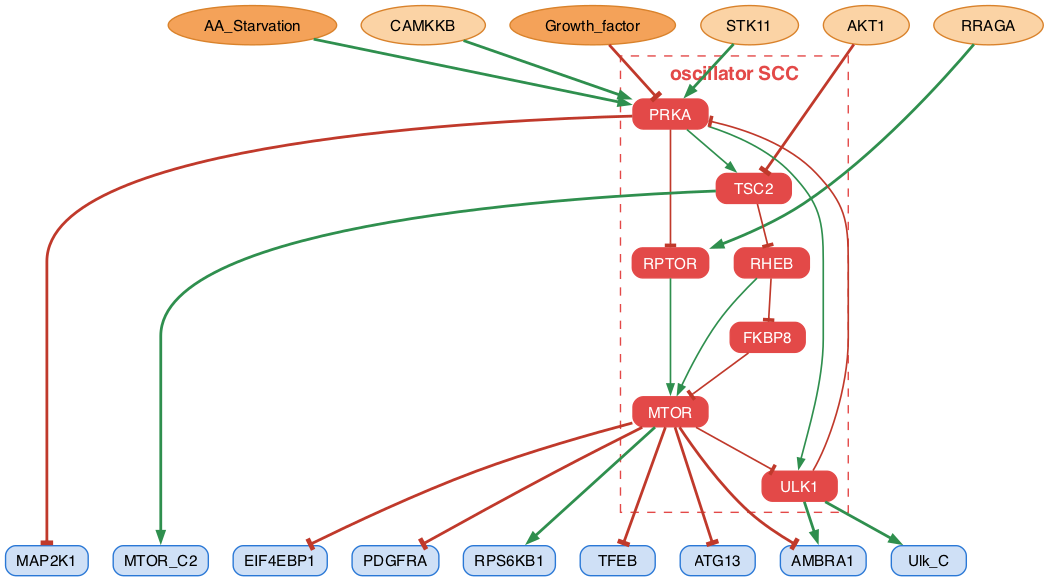

In [7]:
output_edges = sorted(((a, b) for a, b in full.edges if a in OSC and b not in OSC),
                      key=lambda e: (OSC.index(e[0]), e[1]))
receivers = sorted({b for _, b in output_edges})
SIGN_COLOR = {"+": "#2f8f4e", "-": "#c0392b"}

def edge_attrs(a, b, bold=False):
    s = full[a][b]["sign"]
    return dict(color=SIGN_COLOR[s], arrowhead="normal" if s == "+" else "tee", arrowsize="0.7",
                penwidth="2" if bold else "1.2")

A = pgv.AGraph(directed=True, rankdir="TB", nodesep="0.25", ranksep="0.45", fontname="Helvetica")
A.node_attr.update(fontname="Helvetica", fontsize="11", style="filled", height="0.3")
for v in senders:
    A.add_node(v, shape="ellipse", fillcolor="#fbd3a5" if v not in INPUTS else "#f4a259", color="#d9822b")
for v in OSC:
    A.add_node(v, shape="box", style="rounded,filled", fillcolor="#e34948", fontcolor="white", color="#e34948")
for v in receivers:
    A.add_node(v, shape="box", style="rounded,filled", fillcolor="#cfe0f6", color="#2a78d6")
for a, b in full.subgraph(OSC).edges:
    A.add_edge(a, b, **edge_attrs(a, b))
for a, b in input_edges + output_edges:
    A.add_edge(a, b, **edge_attrs(a, b, bold=True))
A.add_subgraph(senders, name="inputs", rank="min")
A.add_subgraph(receivers, name="outputs", rank="max")
A.add_subgraph(OSC, name="cluster_osc", label="oscillator SCC", style="dashed", color="#e34948",
               fontcolor="#e34948", fontname="Helvetica-Bold")
Image(A.draw(format="png", prog="dot", args="-Gdpi=100"))

## 3 — What the inputs do

### Effective rule of each landing node

For every combination of values of a landing node's external regulators, substitute them into its
rule and simplify. What remains is the rule the SCC sees.

In [8]:
def effective(v, values):
    f = EXPR[v].subs({SYM[k]: bool(x) for k, x in values.items()})
    if not satisfiable(~f):                     # simplify_logic can leave tautologies like A | ~A
        return sympy.true
    if not satisfiable(f):
        return sympy.false
    return simplify_logic(f, form="dnf")

def landing_table(v):
    ext = [a for a in full.predecessors(v) if a not in OSC]
    rows = [{**{a: str(x) for a, x in zip(ext, vals)}, "effective rule": str(effective(v, dict(zip(ext, vals))))}
            for vals in itertools.product([0, 1], repeat=len(ext))]
    return pd.DataFrame(rows)

prka = landing_table("PRKA")
prka["effective rule"].value_counts().rename("combinations of the 4 inputs").to_frame()

,combinations of the 4 inputs
effective rule,
~ULK1,15
False,1


In [9]:
# The single combination that switches PRKA off for good
prka[prka["effective rule"] == "False"]

,AA_Starvation,CAMKKB,Growth_factor,STK11,effective rule
2,0,0,1,0,False


In [10]:
pd.concat({v: landing_table(v) for v in ["TSC2", "RPTOR"]}, names=["landing node", ""]).fillna("")

AKT1 effective rule RRAGA
landing node                            
TSC2         0    0           PRKA      
             1    1          False      
RPTOR        0               False     0
             1               ~PRKA     1

* **`PRKA`** is `!ULK1` (the negative feedback loop is closed) in 15 of the 16 combinations of its
  four inputs. Only one combination switches AMPK off permanently: **growth factor ON with no
  activator at all** (no amino-acid starvation, no LKB1/`STK11`, no `CAMKKB`). Any single stress
  activator restores the loop, so growth factor cannot stop AMPK on its own.
* **`TSC2`** follows `PRKA` unless `AKT1` is ON, which pins it OFF.
* **`RPTOR`** follows `!PRKA` only when the amino-acid sensor `RRAGA` is ON. Without amino
  acids it is pinned OFF, and so is `MTOR`.

### Dynamics of the isolated SCC under every input combination

Fix the six senders at every one of their $2^6 = 64$ combinations of values, build the asynchronous
state transition graph of the 7 SCC nodes (128 states), and find its attractors (terminal SCCs of
the STG).

In [11]:
OSC_FN = {v: sympy.lambdify([SYM[u] for u in OSC + senders], EXPR[v], "math") for v in OSC}

def scc_attractors(context):
    stg = nx.DiGraph()
    ctx = [context[s] for s in senders]
    for state in itertools.product([0, 1], repeat=len(OSC)):
        stg.add_node(state)
        for i, v in enumerate(OSC):
            new = int(bool(OSC_FN[v](*state, *ctx)))
            if new != state[i]:
                stg.add_edge(state, state[:i] + (new,) + state[i + 1:])
    cond = nx.condensation(stg)
    return [sorted(cond.nodes[c]["members"]) for c in cond if cond.out_degree(c) == 0]

def describe(att):
    if len(att) == 1:
        return "fixed: " + (", ".join(v for v, x in zip(OSC, att[0]) if x) or "all OFF") + " ON"
    free = [v for i, v in enumerate(OSC) if len({s[i] for s in att}) > 1]
    return f"oscillation ({len(att)} states): {', '.join(free)}"

regimes = pd.DataFrame([{**ctx, "SCC behaviour": " / ".join(map(describe, scc_attractors(ctx)))}
                        for ctx in (dict(zip(senders, vals))
                                    for vals in itertools.product([0, 1], repeat=len(senders)))])
assert regimes["SCC behaviour"].str.count("/").eq(0).all()     # one attractor per combination

def condition(d):
    # the senders that are constant across the group, written as conditions
    return ", ".join(f"{s}={d[s].iloc[0]}" for s in senders if d[s].nunique() == 1) or "any"

regime_table = (regimes.groupby("SCC behaviour")
                .apply(lambda d: pd.Series({"combinations": len(d), "condition": condition(d)}),
                       include_groups=False)
                .sort_values("combinations", ascending=False))
regime_table

,combinations,condition
SCC behaviour,,
"oscillation (116 states): PRKA, ULK1, MTOR, RPTOR, TSC2, RHEB, FKBP8",15,"RRAGA=1, AKT1=0"
"oscillation (16 states): PRKA, ULK1, MTOR, RPTOR",15,"RRAGA=1, AKT1=1"
"oscillation (32 states): PRKA, ULK1, TSC2, RHEB, FKBP8",15,"RRAGA=0, AKT1=0"
"oscillation (4 states): PRKA, ULK1",15,"RRAGA=0, AKT1=1"
"fixed: MTOR, RPTOR, RHEB ON",2,"AA_Starvation=0, CAMKKB=0, Growth_factor=1, STK11=0, RRAGA=1"
fixed: RHEB ON,2,"AA_Starvation=0, CAMKKB=0, Growth_factor=1, STK11=0, RRAGA=0"


The 64 combinations collapse onto six behaviours, decided by three switches:

| switch | condition | effect |
|---|---|---|
| **AMPK kill** | `Growth_factor` ON and `AA_Starvation`, `STK11`, `CAMKKB` all OFF | `PRKA` is OFF → no oscillation; fixed point |
| **amino-acid gate** | `RRAGA` | ON: `RPTOR`/`MTOR` join the oscillation. OFF: MTOR is stuck OFF |
| **AKT gate** | `AKT1` | OFF: `TSC2`/`RHEB`/`FKBP8` join the oscillation. ON: TSC2 stuck OFF, RHEB stuck ON |

* Whenever AMPK is not killed (60/64 combinations), the **`PRKA ⊣ ULK1` core oscillates**. It is the
  only part of the SCC that always oscillates.
* The full 7-node oscillation (116 states) needs `RRAGA` ON and `AKT1` OFF.
* With the AMPK kill, the SCC settles on MTOR ON (proliferative) if `RRAGA` is ON, and on everything
  OFF except `RHEB` if it is OFF.

## 4 — Which regimes the model's attractors use

The senders' values inside each of the model's attractors (`*` = the sender cycles), grouped by
readout pattern as in `03_attractor_activity_decision`.

In [12]:
GROUP_NAMES = {(0, 0, 1): "Apoptosis", (1, 0, 0): "Proliferation", ("*", "*", "*"): "Cycling",
               ("*", 0, 1): "Apoptosis, proliferation flickers"}
group = pd.Series({k: GROUP_NAMES[tuple(s.get(r, "*") for r in READOUTS)] for k, s in spaces.items()})
senders_in_attractors = pd.DataFrame({k: {v: s.get(v, "*") for v in senders} for k, s in spaces.items()}).T

def regime_of(row):
    if "*" in row.values:
        return "senders not all fixed"
    return regimes.set_index(senders).loc[tuple(row[senders]), "SCC behaviour"]

usage = senders_in_attractors.astype(str).assign(group=group,
                                                 SCC=senders_in_attractors.apply(regime_of, axis=1))
usage.groupby(["group"] + senders + ["SCC"]).size().rename("attractors").to_frame()

KeyError: (0, '*', '*')

No sender cycles in any attractor: all six are fixed, so every attractor sits in one well-defined
regime of the table above. The four readout groups line up with the regimes:

* **Proliferation** (6): the AMPK kill. `Growth_factor` is ON and nothing activates AMPK, so the SCC
  rests on MTOR ON.
* **Cycling** (4): no stress, no growth factor; `RRAGA` ON, `AKT1` OFF. This is the full 7-node
  oscillation.
* **Apoptosis, proliferation flickers** (30): stress turns `CAMKKB` ON through ER stress and Ca²⁺,
  which re-activates AMPK even when growth factor is present. `RRAGA` is ON, so MTOR stays in the
  oscillation (the full one, or the 16-state one when `AKT1` is ON) and proliferation can still
  flicker, while stress fixes apoptosis ON downstream.
* **Apoptosis** (48): amino-acid starvation turns `RRAGA` OFF. MTOR drops out of the oscillation
  (32- or 4-state version), so proliferation is impossible. The `PRKA`–`ULK1` core keeps
  oscillating.

## 5 — Outputs: what leaves the SCC, and where it goes

Every edge from an SCC node to a node outside it. For each receiver:

* **other regulators**: the receiver's regulators outside the SCC;
* **reads the SCC when**: the values of those other regulators for which the receiver's value
  actually depends on the SCC (the gate is open), simplified;
* **reads**: the receiver's rule once the gate is open, as a function of the SCC nodes;
* **downstream**: shortest distance to each readout without passing back through the SCC (`—` if
  unreachable).

In [13]:
def gating(v):
    scc_regs = [a for a in full.predecessors(v) if a in OSC]
    other = [a for a in full.predecessors(v) if a not in OSC]
    open_rows, reads = [], set()
    for vals in itertools.product([0, 1], repeat=len(other)):
        f = effective(v, dict(zip(other, vals)))
        if f.free_symbols:                      # still depends on the SCC: the gate is open
            open_rows.append(dict(zip(other, vals)))
            reads.add(str(f))
    if not other:
        when = "always"
    else:
        minterms = [[r[o] for o in other] for r in open_rows]
        when = str(simplify_logic(sympy.SOPform([SYM[o] for o in other], minterms), form="dnf"))
    return other, when, " or ".join(sorted(reads))

def downstream(v):
    return {r: (nx.shortest_path_length(outside, v, r) if nx.has_path(outside, v, r) else "—")
            for r in READOUTS}

outputs_table = pd.DataFrame([{
    "edge": f"{a} {arrow(a, b)} {b}", "from": a, "receiver rule": RULES[b],
    **dict(zip(["other regulators", "reads the SCC when", "reads"],
               (lambda g: (", ".join(g[0]) or "—", g[1], g[2]))(gating(b)))),
    **{f"→ {r}": d for r, d in downstream(b).items()}}
    for a, b in output_edges])
outputs_table

,edge,from,receiver rule,other regulators,reads the SCC when,reads,→ Proliferation,→ Autop_digestion,→ Apoptosis
0,PRKA → MAP2K1,PRKA,(!PRKA & RAF) | PRKA,RAF,~RAF,PRKA,10,8,11
1,ULK1 → AMBRA1,ULK1,!MTOR & ULK1 & !Caspase_3_6_7_C,Caspase_3_6_7_C,~Caspase_3_6_7_C,ULK1 & ~MTOR,10,6,8
2,ULK1 → Ulk_C,ULK1,ATG13 & RB1CC1 & ULK1 & TRAF6,"ATG13, RB1CC1, TRAF6",ATG13 & RB1CC1 & TRAF6,ULK1,20,6,10
3,MTOR ⊣ AMBRA1,MTOR,!MTOR & ULK1 & !Caspase_3_6_7_C,Caspase_3_6_7_C,~Caspase_3_6_7_C,ULK1 & ~MTOR,10,6,8
4,MTOR ⊣ ATG13,MTOR,!MTOR,—,always,~MTOR,21,7,11
5,MTOR ⊣ EIF4EBP1,MTOR,!MTOR,—,always,~MTOR,2,—,—
6,MTOR ⊣ PDGFRA,MTOR,!MTOR,—,always,~MTOR,8,9,12
7,MTOR → RPS6KB1,MTOR,MTOR,—,always,MTOR,8,10,12
8,MTOR ⊣ TFEB,MTOR,!MTOR & !MAP3K,MAP3K,~MAP3K,~MTOR,—,—,—
9,TSC2 → MTOR_C2,TSC2,TSC2,—,always,TSC2,7,8,11


In [14]:
pd.DataFrame({v: {"outputs": ", ".join(f"{arrow(v, b)} {b}" for a, b in output_edges if a == v) or "—",
                  "n": sum(a == v for a, _ in output_edges)} for v in OSC}).T

,outputs,n
PRKA,→ MAP2K1,1
ULK1,"→ AMBRA1, → Ulk_C",2
MTOR,"⊣ AMBRA1, ⊣ ATG13, ⊣ EIF4EBP1, ⊣ PDGFRA, → RPS6KB1, ⊣ TFEB",6
RPTOR,—,0
TSC2,→ MTOR_C2,1
RHEB,—,0
FKBP8,—,0


* **MTOR is the output hub**: it sends 6 of the 10 output edges, five of them inhibitory (`ATG13`,
  `EIF4EBP1`, `PDGFRA`, `TFEB`, `AMBRA1`) and one activating (`RPS6KB1`). `ULK1` sends two (`AMBRA1`,
  `Ulk_C`), `PRKA` one (`MAP2K1`) and `TSC2` one (`MTOR_C2`). `RPTOR`, `RHEB` and `FKBP8` have no output.
* **Ungated receivers** copy one SCC node directly: `ATG13`, `EIF4EBP1` and `PDGFRA` (= `!MTOR`),
  `RPS6KB1` (= `MTOR`) and `MTOR_C2` (= `TSC2`).
* **Gated receivers** read the SCC only when other nodes allow it:
  * `MAP2K1` reads `PRKA` only when `RAF` is OFF. Growth-factor RAS–RAF signalling overrides it.
  * `AMBRA1` reads `ULK1 & !MTOR` only when the caspases are OFF.
  * `Ulk_C` reads `ULK1` only when `ATG13`, `RB1CC1` and `TRAF6` are ON.
  * `TFEB` reads `!MTOR` only when `MAP3K` is OFF.
* `AMBRA1` is the only receiver that combines two SCC nodes (ULK1 ON *and* MTOR OFF). It is the
  autophagy licence.

### At which phase of the oscillation is each output ON?

Take the full 7-node oscillation (no AMPK kill, `RRAGA` ON, `AKT1` OFF: the regime of the
Cycling attractors) and read each receiver's open-gate function on every state of the attractor.
States are grouped by the phase of the `PRKA`/`ULK1`/`MTOR` clock, in the order of the cycle in
`0X_cyclical_attractor_analysis`. A cell is the fraction of the phase's states in which the receiver is ON.

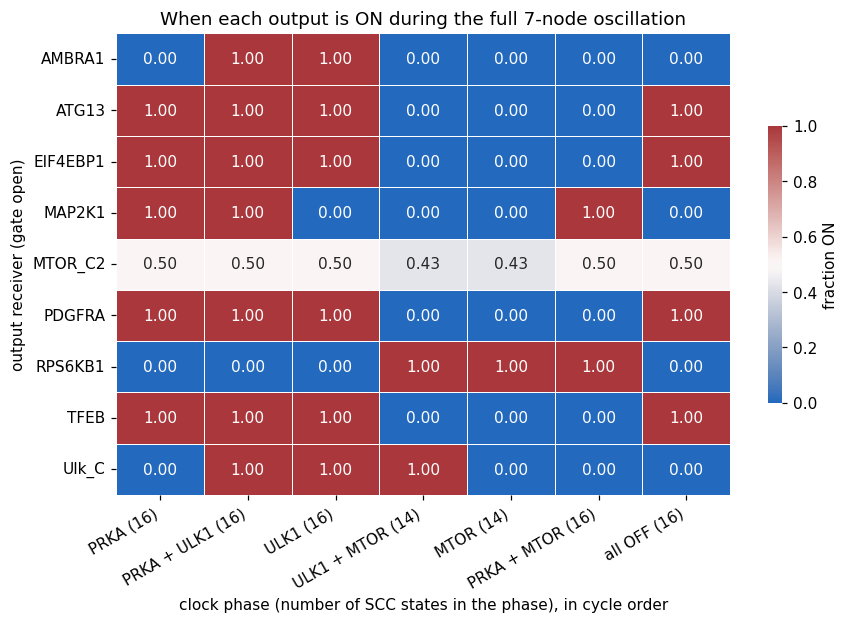

In [15]:
cycle_ctx = {s: 0 for s in senders} | {"RRAGA": 1}
assert regimes.set_index(senders).loc[tuple(cycle_ctx[s] for s in senders), "SCC behaviour"].startswith(
    "oscillation (116")
cycle_states = scc_attractors(cycle_ctx)[0]

PHASES = [(1, 0, 0), (1, 1, 0), (0, 1, 0), (0, 1, 1), (0, 0, 1), (1, 0, 1), (0, 0, 0)]
def phase_name(p):
    return " + ".join(n for n, x in zip(["PRKA", "ULK1", "MTOR"], p) if x) or "all OFF"

read_fn = {}
for b in receivers:
    _, _, reads = gating(b)
    expr = sympy.sympify(reads.replace(" or ", " | "), locals=SYM)
    read_fn[b] = sympy.lambdify([SYM[u] for u in OSC], expr, "math")

phase_rows = {}
for p in PHASES:
    states = [s for s in cycle_states if s[:3] == p]
    if states:
        phase_rows[f"{phase_name(p)} ({len(states)})"] = {
            b: np.mean([bool(read_fn[b](*s)) for s in states]) for b in receivers}
phase_map = pd.DataFrame(phase_rows)

fig, ax = plt.subplots(figsize=(9, 0.45 * len(receivers) + 1.4))
sns.heatmap(phase_map, cmap=sns.color_palette("vlag", as_cmap=True), vmin=0, vmax=1, annot=True,
            fmt=".2f", linewidths=0.5, linecolor="white", cbar_kws={"label": "fraction ON", "shrink": 0.6},
            ax=ax)
ax.set_xlabel("clock phase (number of SCC states in the phase), in cycle order")
ax.set_ylabel("output receiver (gate open)")
ax.set_title("When each output is ON during the full 7-node oscillation")
plt.xticks(rotation=30, ha="right")
plt.show()

The clock broadcasts three phase signals, one per readout branch. In the cycle order of `0X_cyclical_attractor_analysis`:

* **PRKA phases** (`PRKA`, `PRKA + ULK1`, `PRKA + MTOR`): `MAP2K1` is ON. This is the start of the
  MAP3K → JNK (`MAPK8`) ⊣ BCL2 route to apoptosis.
* **ULK1 without MTOR** (`PRKA + ULK1`, `ULK1`): `AMBRA1` is ON, the autophagy licence. `Ulk_C`
  reads only `ULK1`, so it stays ON into `ULK1 + MTOR`. In the full model MTOR also reaches `Ulk_C`
  through `ATG13` (= `!MTOR`), one step later.
* **MTOR phases** (`ULK1 + MTOR`, `MTOR`, `PRKA + MTOR`): `RPS6KB1` is ON, and the four `!MTOR`
  receivers (`ATG13`, `EIF4EBP1`, `PDGFRA`, `TFEB`) are OFF. `EIF4EBP1` OFF frees `EIF4E`, which is
  the proliferation signal.
* `MTOR_C2` (= `TSC2`) is ON in about half the states of every phase. The TSC2 arm is not locked to
  the PRKA/ULK1/MTOR clock.

So one turn of the clock sends the apoptosis signal (PRKA), then the autophagy licence (ULK1 without
MTOR), then the proliferation signal (MTOR).

### Routes from the SCC to the readouts

For each SCC node that has an output and each readout, the shortest path that leaves the SCC
once and never comes back.

In [16]:
exits = [v for v in OSC if any(a == v for a, _ in output_edges)]
routes = {}
for s in exits:
    g = full.subgraph((set(names) - set(OSC)) | {s})
    for r in READOUTS:
        if nx.has_path(g, s, r):
            routes[(s, r)] = nx.shortest_path(g, s, r)
pd.DataFrame([{"from": s, "readout": r, "steps": len(p) - 1, "route": signed_path(p)}
              for (s, r), p in routes.items()]).pivot(index="from", columns="readout", values="steps")

readout,Apoptosis,Autop_digestion,Proliferation
from,,,
MTOR,9,7,3
PRKA,12,9,11
TSC2,12,9,8
ULK1,9,7,11


A shortest path is structural: some of its edges may be switched off by the other regulators of
their target. The last column marks the routes whose nodes all cycle in the Cycling attractors (P5).
`02_structural_scc_analysis` showed that every edge between two such nodes is functional there, so these routes are the
ones that actually carry the oscillation to the readouts in the Cycling regime.

In [17]:
route_table = pd.DataFrame([{"from": s, "readout": r, "steps": len(p) - 1, "route": signed_path(p),
                             "active in Cycling": all(v in cycling for v in p)}
                            for (s, r), p in routes.items()])
route_table.sort_values(["readout", "steps"], ignore_index=True)

,from,readout,steps,route,active in Cycling
0,ULK1,Apoptosis,9,ULK1 → AMBRA1 → TRAF6 → IKBKB ⊣ NFKBIA ⊣ NFkappaB → FLIP ⊣ CASP8 → Caspase_3_6_7_C → Apoptosis,False
1,MTOR,Apoptosis,9,MTOR ⊣ AMBRA1 → TRAF6 → IKBKB ⊣ NFKBIA ⊣ NFkappaB → FLIP ⊣ CASP8 → Caspase_3_6_7_C → Apoptosis,False
2,PRKA,Apoptosis,12,PRKA → MAP2K1 → MAP3K → DAPK1 → PRKD1 → MAPK8 ⊣ BCL2 ⊣ BAX → MOMP → Cyt_C → Caspase9_APAF1_C → Caspase_3_6_7_C → Apoptosis,True
3,TSC2,Apoptosis,12,TSC2 → MTOR_C2 → AKT1 ⊣ FOXO ⊣ TP53_nuc → mRNA_BCL2L11 → BCL2L11 → BAX → MOMP → Cyt_C → Caspase9_APAF1_C → Caspase_3_6_7_C → Apoptosis,False
4,ULK1,Autop_digestion,7,ULK1 → AMBRA1 → BECN1 → PIK3C3 → UVRAG → RAB7A → Atphgo_mat → Autop_digestion,True
5,MTOR,Autop_digestion,7,MTOR ⊣ AMBRA1 → BECN1 → PIK3C3 → UVRAG → RAB7A → Atphgo_mat → Autop_digestion,True
6,PRKA,Autop_digestion,9,PRKA → MAP2K1 → MAP3K ⊣ BCL2_BECN1_C ⊣ BECN1 → PIK3C3 → UVRAG → RAB7A → Atphgo_mat → Autop_digestion,False
7,TSC2,Autop_digestion,9,TSC2 → MTOR_C2 → AKT1 → YWHAB ⊣ BECN1 → PIK3C3 → UVRAG → RAB7A → Atphgo_mat → Autop_digestion,False
8,MTOR,Proliferation,3,MTOR ⊣ EIF4EBP1 ⊣ EIF4E → Proliferation,True
9,TSC2,Proliferation,8,TSC2 → MTOR_C2 → AKT1 ⊣ FOXO ⊣ TP53_nuc → p21 → pRB ⊣ Cell_cycle → Proliferation,False


In [18]:
# Shortest route from each exit node to each readout using only nodes that cycle in P5
cyc_routes = {}
for s in exits:
    g = full.subgraph(cycling - (set(OSC) - {s}))
    for r in READOUTS:
        if nx.has_path(g, s, r):
            cyc_routes[(s, r)] = nx.shortest_path(g, s, r)
pd.DataFrame([{"from": s, "readout": r, "steps": len(p) - 1, "route": signed_path(p)}
              for (s, r), p in cyc_routes.items()]).sort_values(["readout", "steps"], ignore_index=True)

,from,readout,steps,route
0,ULK1,Apoptosis,11,ULK1 → AMBRA1 → BECN1 → PIK3C3 → UVRAG → RAB7A → Atphgo_mat ⊣ MOMP → Cyt_C → Caspase9_APAF1_C → Caspase_3_6_7_C → Apoptosis
1,MTOR,Apoptosis,11,MTOR ⊣ AMBRA1 → BECN1 → PIK3C3 → UVRAG → RAB7A → Atphgo_mat ⊣ MOMP → Cyt_C → Caspase9_APAF1_C → Caspase_3_6_7_C → Apoptosis
2,PRKA,Apoptosis,12,PRKA → MAP2K1 → MAP3K → DAPK1 → PRKD1 → MAPK8 ⊣ BCL2 ⊣ BAX → MOMP → Cyt_C → Caspase9_APAF1_C → Caspase_3_6_7_C → Apoptosis
3,ULK1,Autop_digestion,7,ULK1 → AMBRA1 → BECN1 → PIK3C3 → UVRAG → RAB7A → Atphgo_mat → Autop_digestion
4,MTOR,Autop_digestion,7,MTOR ⊣ AMBRA1 → BECN1 → PIK3C3 → UVRAG → RAB7A → Atphgo_mat → Autop_digestion
5,PRKA,Autop_digestion,17,PRKA → MAP2K1 → MAP3K → DAPK1 → PRKD1 → MAPK8 ⊣ BCL2 ⊣ BAX → MOMP → Cyt_C → Caspase9_APAF1_C → Caspase_3_6_7_C ⊣ BECN1 → PIK3C3 → UVRAG → RAB7A → Atphgo_mat → Autop_digestion
6,MTOR,Proliferation,3,MTOR ⊣ EIF4EBP1 ⊣ EIF4E → Proliferation


* Structurally, every exit node reaches every readout. But most of the shortest routes pass through
  nodes that are fixed in the Cycling attractors, for example the TNF → NF-κB → CASP8 branch or
  AKT1 → FOXO → p53. Those routes carry nothing there.
* The routes that are active in the Cycling attractors give **one exit per readout**:
  * **Proliferation** ← `MTOR ⊣ EIF4EBP1 ⊣ EIF4E → Proliferation` (3 steps).
  * **Autophagy** ← `ULK1`/`MTOR` → `AMBRA1 → BECN1 → … → Atphgo_mat → Autop_digestion` (7 steps).
  * **Apoptosis** ← `PRKA → MAP2K1 → MAP3K → DAPK1 → PRKD1 → MAPK8 ⊣ BCL2 ⊣ BAX → MOMP → … →
    Apoptosis` (12 steps). The autophagy arm reaches apoptosis only negatively, through
    `Atphgo_mat ⊣ MOMP`.
* In this model `KEAP1` is the constant 0, so `BCL2 = !MAPK8 & mRNA_BCL2`, and apoptosis is driven
  by the PRKA → JNK route. In the October model (`autophagy_and_apoptosis_oct26/03_attractor_activity_decision`) the
  apoptosis arm follows `KEAP1`/autophagic flux instead. The two revisions differ here.

### Figure: the SCC in context

The SCC, its receivers (blue), the routes that are active in the Cycling attractors (last table)
leading to the readouts (dark), and the senders (orange) with their shortest route from the closest
environmental input (grey).

47 nodes drawn


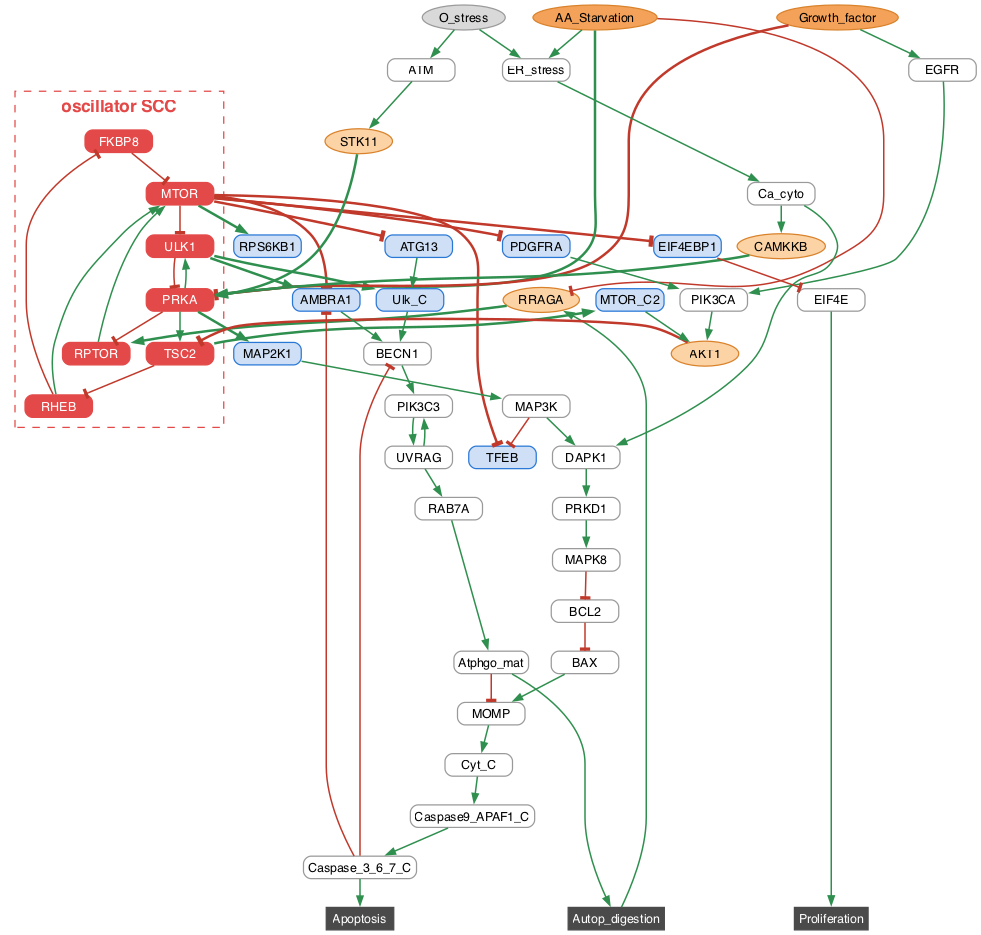

In [19]:
context = set(OSC) | set(senders) | set(receivers) | set(READOUTS)
for a in senders:
    if a not in INPUTS:
        context |= set(nx.shortest_path(outside, next(iter(environment(a))), a))
for p in cyc_routes.values():
    context |= set(p)

A = pgv.AGraph(directed=True, rankdir="TB", nodesep="0.18", ranksep="0.32", fontname="Helvetica")
A.node_attr.update(fontname="Helvetica", fontsize="10", style="filled", height="0.25", margin="0.05,0.02")
for v in sorted(context):
    if v in OSC:
        A.add_node(v, shape="box", style="rounded,filled", fillcolor="#e34948", fontcolor="white", color="#e34948")
    elif v in senders:
        A.add_node(v, shape="ellipse", fillcolor="#f4a259" if v in INPUTS else "#fbd3a5", color="#d9822b")
    elif v in INPUTS:
        A.add_node(v, shape="ellipse", fillcolor="#d9d9d9", color="#9a9a9a")
    elif v in receivers:
        A.add_node(v, shape="box", style="rounded,filled", fillcolor="#cfe0f6", color="#2a78d6")
    elif v in READOUTS:
        A.add_node(v, shape="box", fillcolor="#4a4a4a", fontcolor="white", color="#4a4a4a")
    else:
        A.add_node(v, shape="box", style="rounded,filled", fillcolor="white", color="#9a9a9a")
for a, b in full.subgraph(context).edges:
    if a == b:
        continue
    crossing = (a in OSC) != (b in OSC)
    A.add_edge(a, b, **edge_attrs(a, b, bold=crossing))
A.add_subgraph(OSC, name="cluster_osc", label="oscillator SCC", style="dashed", color="#e34948",
               fontcolor="#e34948", fontname="Helvetica-Bold")
A.add_subgraph([v for v in INPUTS if v in context], name="env", rank="min")
A.add_subgraph(READOUTS, name="readouts", rank="max")
print(f"{len(context)} nodes drawn")
Image(A.draw(format="png", prog="dot", args="-Gdpi=90"))

## 6 — Outer loops: from an output back to an input

For every pair (receiver, sender) the shortest path from the receiver to the sender that stays
outside the SCC. Together with the exit and entry edges it forms a loop through the outside of the
SCC. These are the loops that make the SCC part of a 68-node SCC in the full graph, and that the
cycling-subnetwork construction of `02_structural_scc_analysis` cuts.

In [20]:
outer = []
for a, b in output_edges:
    for c, d in input_edges:
        if nx.has_path(outside, b, c):
            path = [a] + nx.shortest_path(outside, b, c) + [d]
            outer.append({"exit": f"{a} {arrow(a, b)} {b}", "entry": f"{c} {arrow(c, d)} {d}",
                          "outside steps": len(path) - 3,
                          "route": signed_path(path),
                          "sign exit→entry": "-" if sum(full[x][y]["sign"] == "-" for x, y in zip(path, path[1:])) % 2 else "+"})
outer = pd.DataFrame(outer)
outer.sort_values("outside steps").drop_duplicates("entry", keep="first").reset_index(drop=True)

,exit,entry,outside steps,route,sign exit→entry
0,TSC2 → MTOR_C2,AKT1 ⊣ TSC2,1,TSC2 → MTOR_C2 → AKT1 ⊣ TSC2,-
1,ULK1 → AMBRA1,RRAGA → RPTOR,7,ULK1 → AMBRA1 → BECN1 → PIK3C3 → UVRAG → RAB7A → Atphgo_mat → Autop_digestion → RRAGA → RPTOR,+


In [21]:
# How many receivers can reach each sender (all exit/entry pairs)
outer.pivot_table(index="exit", columns="entry", values="outside steps", aggfunc="min").fillna("—")

entry,AKT1 ⊣ TSC2,RRAGA → RPTOR
exit,,
MTOR → RPS6KB1,3,11
MTOR ⊣ AMBRA1,4,7
MTOR ⊣ ATG13,15,8
MTOR ⊣ PDGFRA,2,10
PRKA → MAP2K1,7,9
TSC2 → MTOR_C2,1,9
ULK1 → AMBRA1,4,7
ULK1 → Ulk_C,14,7


Exactly two outer loops come back into the SCC, one through each fed-back sender. The four
environmental senders are never downstream of the SCC.

* **mTORC2–AKT loop**: `TSC2 → MTOR_C2 → AKT1 ⊣ TSC2`, one outside step. It is negative on TSC2.
  `AKT1` is OFF in all the Cycling attractors and in 60 of the other 84 (section 4), so this loop is
  open there.
* **Amino-acid refeeding loop**: `ULK1 → AMBRA1 → BECN1 → … → Autop_digestion → RRAGA → RPTOR`,
  seven outside steps. Closing it inside the SCC (`RPTOR → MTOR ⊣ ULK1`) makes it negative: autophagy
  restores amino acids, which brings MTOR back, which shuts autophagy down. It matters only under
  amino-acid starvation (`RRAGA = !AA_Starvation | AA_Starvation & Autop_digestion`). In the
  Apoptosis attractors digestion is OFF, so `RRAGA` stays OFF and the loop cannot refeed MTOR.

Every exit can reach both `AKT1` and `RRAGA` (matrix above), but always through one of these two
entries.

## Summary

* **Inputs: 6 edges, landing on 3 of the 7 nodes.**
  * `PRKA` (AMPK) is the main entry, with 4 inputs: `Growth_factor ⊣`, `AA_Starvation →`,
    `STK11 →` and `CAMKKB →`.
  * `TSC2` (`AKT1 ⊣`) and `RPTOR` (`RRAGA →`) are side entries on the MTOR arm.
  * `ULK1`, `MTOR`, `RHEB` and `FKBP8` receive no input.
* **The senders.** Four are purely environmental: growth factor and amino-acid starvation act
  directly, oxidative stress acts through `ATM → STK11`, and ER stress through `Ca²⁺ → CAMKKB`. Two
  are also fed back from the SCC: `AKT1` via mTORC2, and `RRAGA` via autophagic digestion.
* **The inputs act as three switches.**
  * The *AMPK kill* (growth factor ON with no AMPK activator) stops the clock with MTOR ON.
  * `RRAGA` decides whether MTOR takes part in the oscillation.
  * `AKT1` decides whether `TSC2`/`RHEB`/`FKBP8` take part.

  The `PRKA ⊣ ULK1` core oscillates in 60 of the 64 input combinations.
* **The four readout groups are four input regimes.**
  * Proliferation = AMPK kill.
  * Cycling = full oscillation, no stress.
  * Apoptosis with flickering proliferation = oscillation including MTOR, plus stress.
  * Apoptosis = oscillation without MTOR (amino-acid starvation).
* **Outputs: 10 edges from 4 nodes** (MTOR 6, ULK1 2, PRKA 1, TSC2 1). `RPTOR`, `RHEB` and
  `FKBP8` are internal only.
* **Each readout has its own exit, read at its own phase of the clock.**
  * PRKA phase → `MAP2K1` → JNK ⊣ BCL2 → apoptosis.
  * ULK1 without MTOR → `AMBRA1` → BECN1 → autophagy.
  * MTOR phase → `EIF4EBP1` OFF → `EIF4E` → proliferation.
* **Gates.** Several outputs pass only when nodes outside the SCC allow it: `RAF` (MAP2K1), the
  caspases (AMBRA1), `MAP3K` (TFEB), and `ATG13`/`RB1CC1`/`TRAF6` (Ulk_C).
* **Two outer loops** close the SCC into the 68-node SCC of the full graph: mTORC2–AKT on TSC2, and
  amino-acid refeeding through autophagy on RPTOR.
* **Caveats.**
  * Section 3 fixes the senders, although `AKT1` and `RRAGA` are fed back. Section 4 shows that all
    six senders are fixed in every attractor, so this is exact for the attractors, but not for
    transients.
  * Everything here is for the **September** model; the apoptosis exit differs in the October
    revision.